In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)


In [2]:
# Project paths
PROJECT_ROOT = Path("/Users/sean.lewis/DataspellProjects/multi_agent_ds")
RAW_DIR = PROJECT_ROOT / "data" / "raw"

SUPPORTED_EXTENSIONS = {".parquet", ".csv", ".json", ".xlsx", ".xls"}

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw data directory not found: {RAW_DIR}")

all_files = sorted([p for p in RAW_DIR.iterdir() if p.is_file()])
dataset_files = [p for p in all_files if p.suffix.lower() in SUPPORTED_EXTENSIONS]
skipped_files = [p for p in all_files if p.suffix.lower() not in SUPPORTED_EXTENSIONS]

print(f"Raw directory: {RAW_DIR}")
print(f"Discovered files: {len(all_files)}")
print(f"Supported datasets: {len(dataset_files)}")

if skipped_files:
    print("Skipped unsupported files:")
    for p in skipped_files:
        print(f"  - {p.name}")

display(pd.DataFrame({"dataset": [p.name for p in dataset_files]}))


Raw directory: /Users/sean.lewis/DataspellProjects/multi_agent_ds/data/raw
Discovered files: 2
Supported datasets: 1
Skipped unsupported files:
  - .gitkeep


,dataset
0,synthetic_dataset.parquet


In [3]:
def load_dataset(file_path: Path) -> pd.DataFrame:
    suffix = file_path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(file_path)
    if suffix == ".csv":
        return pd.read_csv(file_path)
    if suffix == ".json":
        # Common tabular JSON format
        return pd.read_json(file_path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(file_path)
    raise ValueError(f"Unsupported file extension: {suffix}")


def basic_eda(df: pd.DataFrame, dataset_name: str) -> None:
    print("=" * 88)
    print(f"EDA: {dataset_name}")
    print("=" * 88)

    if df.empty:
        print("Dataset is empty.")
        return

    n_rows, n_cols = df.shape
    mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"Shape: {n_rows:,} rows x {n_cols:,} columns")
    print(f"Memory usage: {mem_mb:.2f} MB")

    print("\nPreview")
    display(df.head(5))

    print("\nColumn types")
    dtype_df = pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values})
    display(dtype_df)

    print("\nMissing values")
    missing = (
        df.isna()
        .sum()
        .to_frame("missing_count")
        .assign(missing_pct=lambda x: (x["missing_count"] / len(df)).round(4))
        .sort_values("missing_count", ascending=False)
    )
    display(missing)

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

    print("\nNumeric summary")
    if numeric_cols:
        display(df[numeric_cols].describe().T)
    else:
        print("No numeric columns found.")

    print("\nCategorical summary")
    if categorical_cols:
        cat_summary = pd.DataFrame(
            {
                "unique_values": df[categorical_cols].nunique(dropna=True),
                "missing_count": df[categorical_cols].isna().sum(),
            }
        ).sort_values("unique_values", ascending=False)
        display(cat_summary)

        top_col = categorical_cols[0]
        top_counts = df[top_col].astype("string").fillna("<NA>").value_counts().head(20)
        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_counts.index, y=top_counts.values)
        plt.title(f"Top values in {top_col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No categorical columns found.")

    if numeric_cols:
        # Limit plots to keep notebook readable
        plot_cols = numeric_cols[: min(4, len(numeric_cols))]
        df[plot_cols].hist(figsize=(12, 6), bins=30)
        plt.suptitle("Numeric Distributions")
        plt.tight_layout()
        plt.show()



EDA: synthetic_dataset.parquet
Shape: 5,000 rows x 18 columns
Memory usage: 0.84 MB

Preview


,driver_age,annual_income,credit_score,vehicle_value,annual_premium,claim_amount_avg,miles_driven_annual,distance_to_work,num_prior_claims,policy_tenure_months,num_vehicles,num_drivers_on_policy,state,vehicle_type,coverage_tier,marital_status,education_level,binary_target
0,81.636070,241173.259980,683.938620,48115.284533,4872.981456,32281.560562,39230.521420,56.082338,10,159,5,4,CA,sedan,standard,single,doctorate,0
1,43.349005,72139.447873,518.537195,65011.162052,6551.508246,36696.082043,11203.420469,46.853457,0,142,6,5,NC,hatchback,liability_only,married,high_school,1
2,31.426480,120315.613253,653.163178,7979.628296,3358.233154,47864.139215,32179.627239,21.799361,4,106,5,4,NY,sedan,standard,widowed,masters,0
3,25.887128,136626.746123,599.216571,25981.704608,7107.889694,8168.112185,5053.469628,76.995607,0,96,4,2,GA,suv,premium,widowed,doctorate,0
4,30.382164,47497.351650,478.536026,4108.112419,4090.142760,48552.027509,22134.676370,23.162820,7,9,2,5,CA,truck,basic,married,doctorate,0



Column types


,column,dtype
0,driver_age,float64
1,annual_income,float64
2,credit_score,float64
3,vehicle_value,float64
4,annual_premium,float64
5,claim_amount_avg,float64
6,miles_driven_annual,float64
7,distance_to_work,float64
8,num_prior_claims,int64
9,policy_tenure_months,int64



Missing values


,missing_count,missing_pct
driver_age,0,0.0
annual_income,0,0.0
education_level,0,0.0
marital_status,0,0.0
coverage_tier,0,0.0
vehicle_type,0,0.0
state,0,0.0
num_drivers_on_policy,0,0.0
num_vehicles,0,0.0
policy_tenure_months,0,0.0



Numeric summary


,count,mean,std,min,25%,50%,75%,max
driver_age,5000.0,49.978052,19.457649,17.496170,33.242447,49.180819,66.848563,84.473914
annual_income,5000.0,134601.067335,68026.453410,17926.220844,75058.724489,136059.017698,195775.809819,246854.375163
credit_score,5000.0,578.213075,159.150065,303.307745,441.422764,579.920234,714.886879,849.505286
vehicle_value,5000.0,38707.149740,23368.031984,2100.199848,18132.868314,37740.111038,59137.060698,79893.268711
annual_premium,5000.0,4245.786631,2296.553614,418.965028,2194.372222,4261.245766,6347.421109,7949.569823
claim_amount_avg,5000.0,26204.825187,14767.226812,39.760938,13357.435174,26821.253383,39404.687720,49969.837952
miles_driven_annual,5000.0,25218.620981,14354.243363,1201.634255,12714.075958,24994.170717,37568.213423,49829.401191
distance_to_work,5000.0,42.711322,23.241560,2.045919,22.460889,43.134519,63.780934,79.900574
num_prior_claims,5000.0,5.860400,3.815681,0.000000,2.000000,6.000000,9.000000,12.000000
policy_tenure_months,5000.0,121.367000,69.789200,6.000000,60.000000,122.000000,183.000000,238.000000



Categorical summary


,unique_values,missing_count
state,10,0
vehicle_type,6,0
education_level,5,0
coverage_tier,4,0
marital_status,4,0


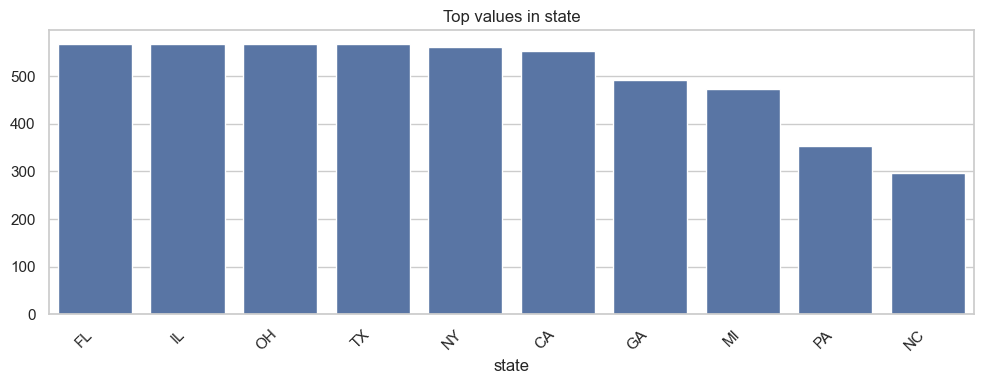

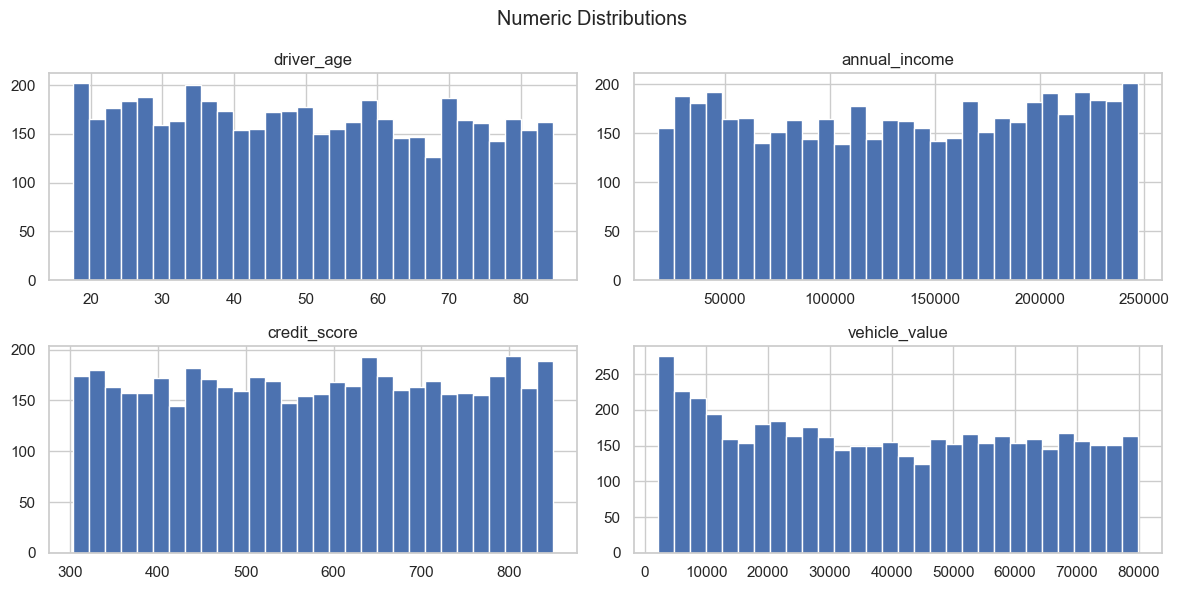

In [4]:
if not dataset_files:
    print("No supported dataset files found in raw directory.")
else:
    for path in dataset_files:
        try:
            df = load_dataset(path)
            basic_eda(df, path.name)
        except Exception as exc:
            print(f"Failed to process {path.name}: {exc}")
